In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ds_salaries.csv to ds_salaries.csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [ ]:
df = pd.read_csv('ds_salaries.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ds_salaries.csv'

In [ ]:
df = pd.read_csv('ds_salaries.csv')

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [ ]:
df.shape

(607, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [ ]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0


In [ ]:
df.duplicated().sum(

)

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

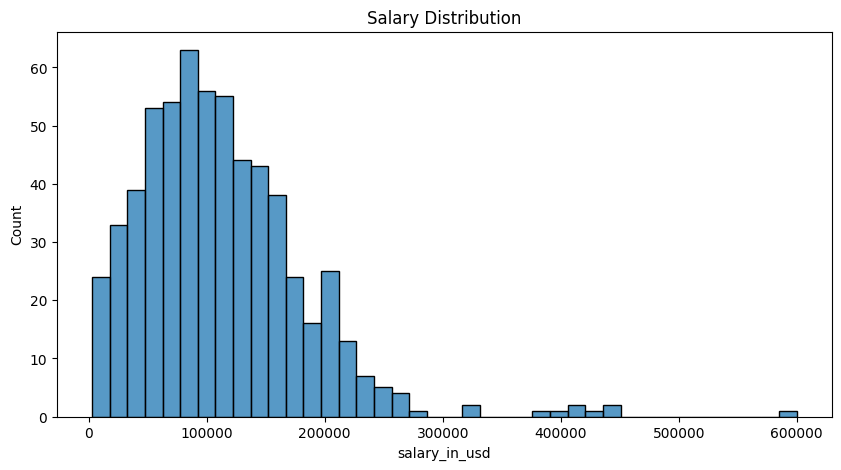

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['salary_in_usd'], bins=40)

plt.title("Salary Distribution")
plt.show()

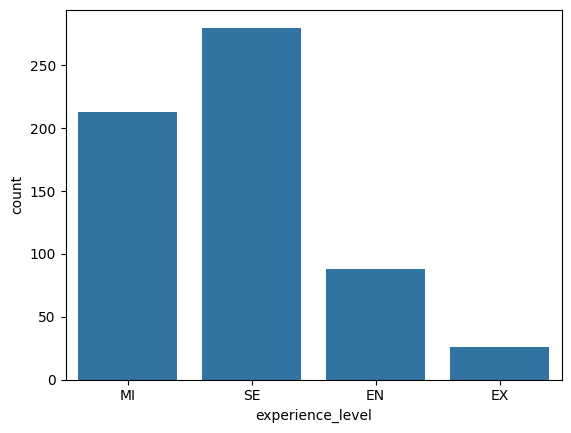

In [ ]:
sns.countplot(
    x='experience_level',
    data=df
)

plt.show()

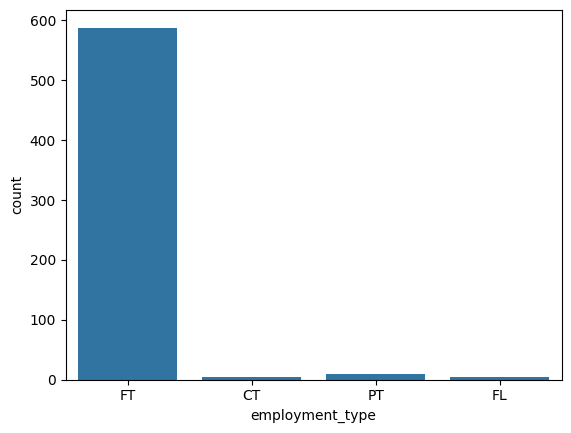

In [ ]:
sns.countplot(
    x='employment_type',
    data=df
)

plt.show()

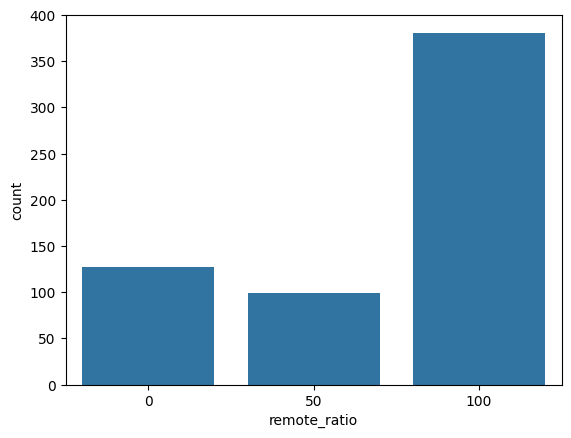

In [ ]:
sns.countplot(
    x='remote_ratio',
    data=df
)

plt.show()

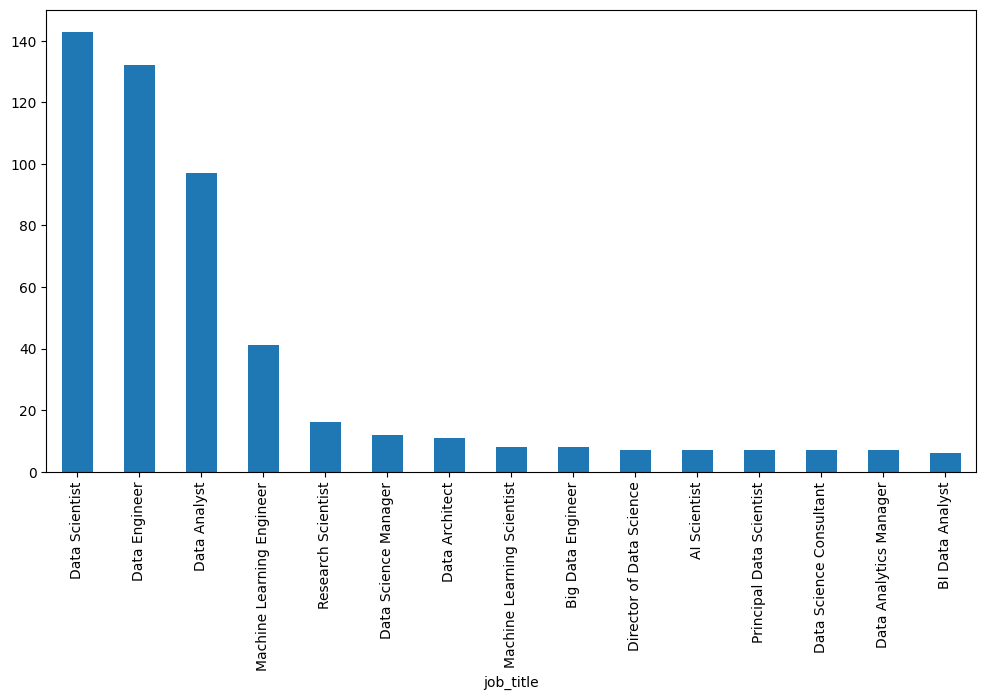

In [ ]:
plt.figure(figsize=(12,6))

df['job_title'].value_counts().head(15).plot(kind='bar')

plt.show()

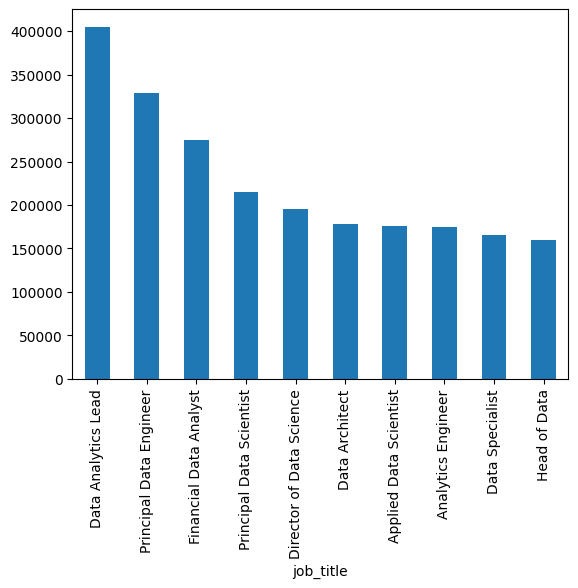

In [ ]:
salary_role = df.groupby(
    'job_title'
)['salary_in_usd'].mean()

salary_role.sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.show()

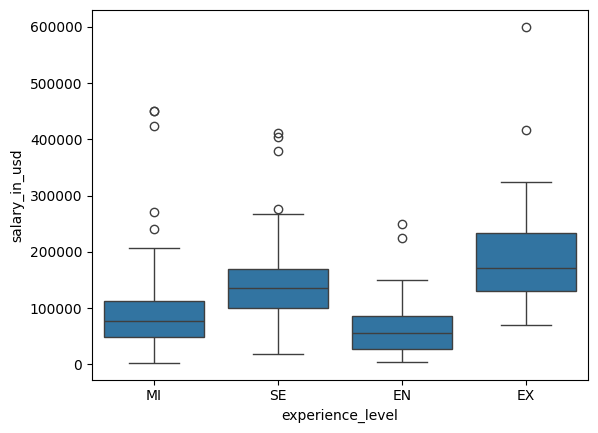

In [ ]:
sns.boxplot(
    x='experience_level',
    y='salary_in_usd',
    data=df
)

plt.show()

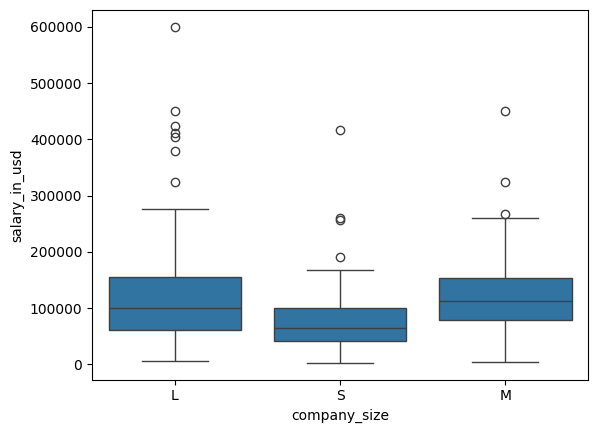

In [ ]:
sns.boxplot(
    x='company_size',
    y='salary_in_usd',
    data=df
)

plt.show()

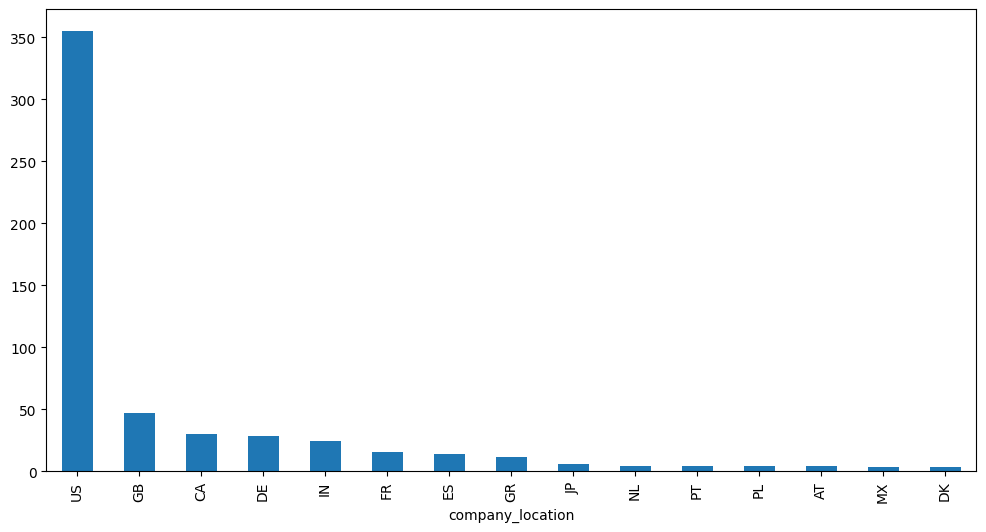

In [ ]:
plt.figure(figsize=(12,6))

df['company_location'] \
.value_counts() \
.head(15) \
.plot(kind='bar')

plt.show()

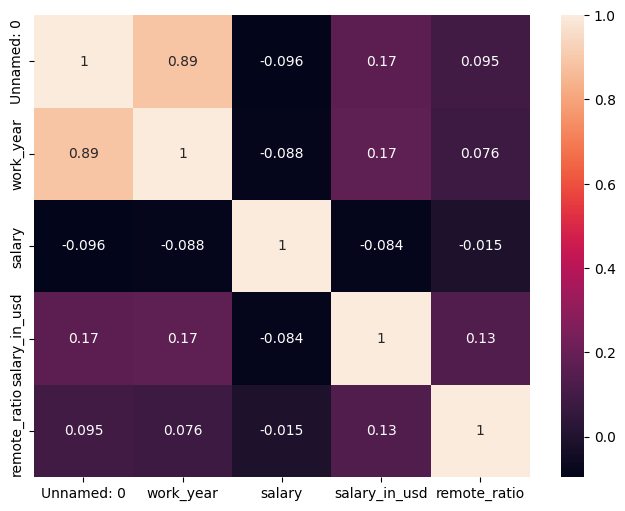

In [ ]:
numeric = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True
)

plt.show()

In [ ]:
fig = px.box(
    df,
    x='experience_level',
    y='salary_in_usd'
)

fig.show()

In [ ]:
fig = px.bar(
    df['job_title']
    .value_counts()
    .head(10)
)

fig.show()

In [ ]:
fig = px.bar(
    df['company_location']
    .value_counts()
    .head(10)
)

fig.show()

In [ ]:
df['salary_category'] = pd.cut(
    df['salary_in_usd'],
    bins=[0,50000,100000,150000,500000],
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

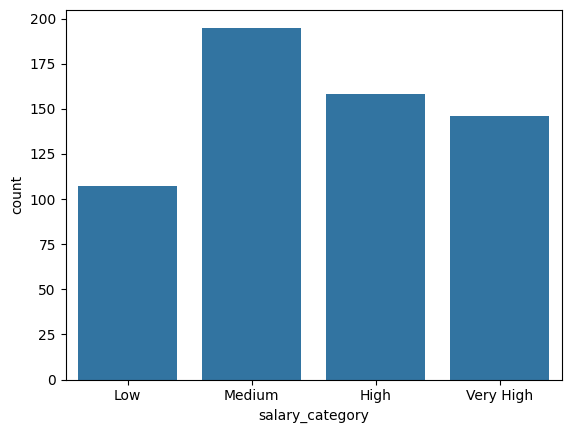

In [ ]:
sns.countplot(
    x='salary_category',
    data=df
)

plt.show()